In [1]:
from PureDefense import PureDefense
import numpy as np
import pandas as pd
import torchvision.transforms as transforms
import torchvision
import torch
import torch.nn as nn
import os
import argparse

from tqdm import tqdm

from diffusers import UNet2DModel, DDPMScheduler


try: 
    import torch_xla.core.xla_model as xm
    import torch_xla
except: pass

from utils.utils import *

from utils.utils_purify import get_poisons, ImageListDataset, save_poisons, process_args, get_ngt

os.environ['XRT_TPU_CONFIG'] = 'localservice;0;localhost:51011'

device = xm.xla_device() 

/home/sunaybhat/.local/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load in 16 test samples from cifar-10
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])
test_data = torchvision.datasets.CIFAR10(root='/home/sunaybhat/data', train=False, download=True, transform=transform)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=16, shuffle=False)
test_data = next(iter(test_loader))
test_images = test_data[0]

Files already downloaded and verified


In [3]:
model_id = "google/ddpm-cifar10-32"
gen = UNet2DModel.from_pretrained(model_id)
gen = gen.to(device)

# Print num params
num_params = sum(p.numel() for p in gen.parameters() if p.requires_grad)
print(f"Number of parameters: {num_params}")

scheduler = DDPMScheduler.from_pretrained(model_id)

Number of parameters: 35746307


In [4]:
Steps = 125

# Run forward process on test_data using diffuser
forward_images = scheduler.add_noise(test_images,torch.randn(test_images.shape),timesteps = torch.LongTensor([Steps])).to(device)


reverse_images = forward_images

for i, t in enumerate(tqdm(scheduler.timesteps[-Steps:])):
    # 1. predict noise residual
    with torch.no_grad():
        residual = gen(reverse_images, t).sample

    # 2. compute previous image and set x_t -> x_t-1
    reverse_images = scheduler.step(residual, t, reverse_images).prev_sample

    xm.mark_step()

forward_images = forward_images.detach().cpu()
reverse_images = reverse_images.detach().cpu()


  0%|          | 0/125 [00:00<?, ?it/s]

100%|██████████| 125/125 [00:31<00:00,  3.93it/s]


(-0.5, 137.5, 137.5, -0.5)

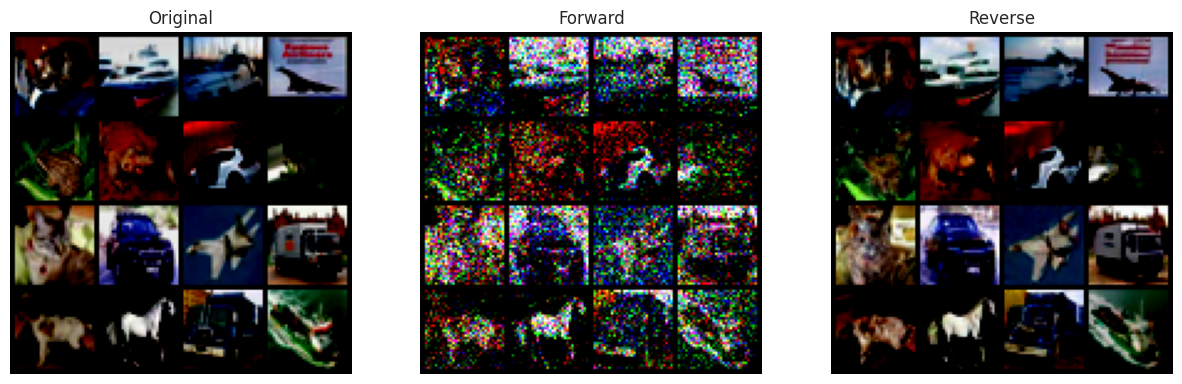

: 

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("darkgrid")
# Plot original, forward, and reverse
fig,axs = plt.subplots(1,3,figsize=(15,5))

# Plot all images, use torch grid
axs[0].imshow(torchvision.utils.make_grid(test_images, nrow=4).permute(1,2,0))
axs[0].set_title("Original")
axs[0].axis("off")

axs[1].imshow(torchvision.utils.make_grid(forward_images.cpu(), nrow=4).permute(1,2,0))
axs[1].set_title("Forward")
axs[1].axis("off")

axs[2].imshow(torchvision.utils.make_grid(reverse_images.cpu(), nrow=4).permute(1,2,0))
axs[2].set_title("Reverse")
axs[2].axis("off")

In [48]:
scheduler.timesteps

tensor([980, 960, 940, 920, 900, 880, 860, 840, 820, 800, 780, 760, 740, 720,
        700, 680, 660, 640, 620, 600, 580, 560, 540, 520, 500, 480, 460, 440,
        420, 400, 380, 360, 340, 320, 300, 280, 260, 240, 220, 200, 180, 160,
        140, 120, 100,  80,  60,  40,  20,   0])